# Project 3: Natural Language Processing and Sentiment Analysis

## Step 1: Import Required Libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import re
import string

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

from wordcloud import WordCloud

import joblib

## Step 2: Download NLTK Resources

In [16]:
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\islam\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\islam\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\islam\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\islam\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\islam\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

## Step 3: Initialize NLP Objects

In [3]:
stemmer = PorterStemmer()

lemmatizer = WordNetLemmatizer()

stop_words = set(stopwords.words("english"))

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


## Step 4: Load the Dataset

For this project, we use a sample IMDB movie review dataset containing positive and negative reviews.

Each review is associated with a sentiment label.

- Positive
- Negative

In [4]:
# Sample dataset demonstrating all concepts

reviews = [
    ("This movie was absolutely fantastic! Best film of the year.", "positive"),
    ("Terrible acting and boring plot. Complete waste of time!", "negative"),
    ("Loved every minute of it. The director did an amazing job.", "positive"),
    ("Awful storyline. I fell asleep halfway through.", "negative"),
    ("Brilliant performances! The cinematography was breathtaking.", "positive"),
    ("Worst movie I have ever seen. Do not waste your money.", "negative"),
    ("Heartwarming and beautifully crafted. A true masterpiece.", "positive"),
    ("Dull and predictable. The script was painfully bad.", "negative"),
]

df = pd.DataFrame(reviews, columns=["review", "sentiment"])

## Step 5: Display the Dataset

Let's inspect the dataset before preprocessing.

In [5]:
print("Dataset Shape:", df.shape)

print("\nFirst Five Rows:")

display(df.head())

Dataset Shape: (8, 2)

First Five Rows:


,review,sentiment
0,This movie was absolutely fantastic! Best film...,positive
1,Terrible acting and boring plot. Complete wast...,negative
2,Loved every minute of it. The director did an ...,positive
3,Awful storyline. I fell asleep halfway through.,negative
4,Brilliant performances! The cinematography was...,positive


## Step 6: Dataset Information

Display basic information about the dataset including column names, data types, and missing values.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     8 non-null      object
 1   sentiment  8 non-null      object
dtypes: object(2)
memory usage: 260.0+ bytes


## Step 7: Check Missing Values

Machine Learning models cannot handle missing text values directly.

Let's verify whether the dataset contains any missing values.

In [7]:
print(df.isnull().sum())

review       0
sentiment    0
dtype: int64


## Step 8: Sentiment Distribution

Check how many reviews belong to each sentiment class.

In [8]:
print(df["sentiment"].value_counts())

sentiment
positive    4
negative    4
Name: count, dtype: int64


## Step 9: Visualize Sentiment Distribution

A count plot provides a quick overview of class balance.

C:\Users\islam\AppData\Local\Temp\ipykernel_36368\1622825181.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


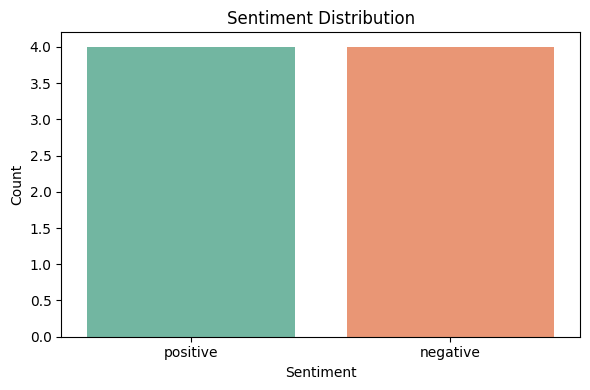

In [9]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="sentiment",
    palette="Set2"
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.tight_layout()

plt.show()

### Observation

The dataset contains both positive and negative reviews. The sentiment distribution helps us determine whether the dataset is balanced before training a machine learning model.

## Task 1: Text Cleaning

Raw text often contains punctuation, numbers, HTML tags, URLs, and unnecessary spaces.

Before applying machine learning, we clean the text so that only meaningful words remain.

### Step 10: Import Regular Expression Library

The `re` library is used for pattern matching and text cleaning.

In [10]:
import re
import string

### Step 11: Create a Text Cleaning Function

The following function performs the following operations:

1. Remove HTML tags
2. Remove URLs
3. Remove punctuation and numbers
4. Convert text to lowercase
5. Remove extra spaces

In [11]:
def clean_text(text):
    """
    Cleans raw text by:
    1. Removing HTML tags
    2. Removing URLs
    3. Removing punctuation and numbers
    4. Converting text to lowercase
    """

    # Remove HTML tags
    text = re.sub(r'<[^>]+>', '', text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove punctuation and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Convert to lowercase
    text = text.lower().strip()

    return text

### Step 12: Test the Cleaning Function

Let's test the cleaning function on a sample sentence.

In [12]:
sample = "The movie was AMAZING!!! Best film of 2024. Visit www.movies.com"

clean = clean_text(sample)

print("Original:")
print(sample)

print("\nCleaned:")
print(clean)

Original:
The movie was AMAZING!!! Best film of 2024. Visit www.movies.com

Cleaned:
the movie was amazing best film of  visit


### Step 13: Apply Text Cleaning to the Dataset

Now we apply the cleaning function to every review in the dataset.

In [13]:
df["cleaned_review"] = df["review"].apply(clean_text)

### Step 14: Compare Original and Cleaned Reviews

Compare the original review with the cleaned version.

In [14]:
for i in range(len(df)):
    print("=" * 70)
    print("Original Review:\n")
    print(df.loc[i, "review"])

    print("\nCleaned Review:\n")
    print(df.loc[i, "cleaned_review"])

Original Review:

This movie was absolutely fantastic! Best film of the year.

Cleaned Review:

this movie was absolutely fantastic best film of the year
Original Review:

Terrible acting and boring plot. Complete waste of time!

Cleaned Review:

terrible acting and boring plot complete waste of time
Original Review:

Loved every minute of it. The director did an amazing job.

Cleaned Review:

loved every minute of it the director did an amazing job
Original Review:

Awful storyline. I fell asleep halfway through.

Cleaned Review:

awful storyline i fell asleep halfway through
Original Review:

Brilliant performances! The cinematography was breathtaking.

Cleaned Review:

brilliant performances the cinematography was breathtaking
Original Review:

Worst movie I have ever seen. Do not waste your money.

Cleaned Review:

worst movie i have ever seen do not waste your money
Original Review:

Heartwarming and beautifully crafted. A true masterpiece.

Cleaned Review:

heartwarming and beaut

### Observation

The cleaning process successfully removes punctuation, numbers, URLs, and converts all text to lowercase, making the reviews ready for tokenization.

### Observation

The cleaning process successfully removes punctuation, numbers, URLs, and converts all text to lowercase, making the reviews ready for tokenization.

In [17]:
text = "the movie was amazing best film"

tokens = word_tokenize(text)

print("Tokens:")
print(tokens)

print("\nToken Count:", len(tokens))

print("\nSimple Split:")
print(text.split())

Tokens:
['the', 'movie', 'was', 'amazing', 'best', 'film']

Token Count: 6

Simple Split:
['the', 'movie', 'was', 'amazing', 'best', 'film']


### Observation

NLTK's `word_tokenize()` performs smarter tokenization than Python's built-in `split()` function.

## Step 16: Load English Stopwords

Stopwords are common words such as:

- the
- is
- was
- a
- and

These words usually do not contribute much to sentiment analysis and are removed.

In [18]:
print("Total Stopwords:", len(stop_words))

print("\nSample Stopwords:")

print(list(stop_words)[:20])

Total Stopwords: 198

Sample Stopwords:
['during', 'out', 'were', 'whom', 'now', 'can', "she'll", "i'm", 'her', 'won', 'an', 'nor', 'ain', 'had', "hasn't", "they'll", 'of', 'was', 'is', 'my']


## Step 17: Remove Stopwords

In [19]:
def remove_stopwords(tokens):
    """
    Remove stopwords and short words.
    """

    filtered = []

    for token in tokens:

        if token not in stop_words and len(token) > 2:
            filtered.append(token)

    return filtered

### Test Stopword Removal

In [20]:
tokens = ["the", "movie", "was", "amazing", "best", "film"]

filtered = remove_stopwords(tokens)

print("Before:")

print(tokens)

print("\nAfter:")

print(filtered)

Before:
['the', 'movie', 'was', 'amazing', 'best', 'film']

After:
['movie', 'amazing', 'best', 'film']


### Observation

Most common English words are removed while meaningful words remain.

## Step 18: Stemming

Stemming reduces words to their root form.

Example:

- running → run
- studies → studi
- happily → happili

In [21]:
words = [
    "running",
    "happily",
    "better",
    "studies",
    "caring",
    "wolves"
]

print("{:<15}{:<20}".format("Word", "Stem"))

print("-"*35)

for word in words:

    print("{:<15}{:<20}".format(
        word,
        stemmer.stem(word)
    ))

Word           Stem                
-----------------------------------
running        run                 
happily        happili             
better         better              
studies        studi               
caring         care                
wolves         wolv                


## Step 19: Lemmatization

Lemmatization converts words into their meaningful dictionary form.

In [22]:
print("{:<15}{:<20}".format("Word", "Lemma"))

print("-"*35)

for word in words:

    print("{:<15}{:<20}".format(
        word,
        lemmatizer.lemmatize(word, pos="v")
    ))

Word           Lemma               
-----------------------------------
running        run                 
happily        happily             
better         better              
studies        study               
caring         care                
wolves         wolves              


### Observation

Compared to stemming, lemmatization usually produces more meaningful words because it uses dictionary information.

## Step 20: Complete Text Preprocessing Pipeline

Now we combine all preprocessing steps into a single reusable function.

The pipeline performs:

1. Text Cleaning
2. Tokenization
3. Stopword Removal
4. Lemmatization
5. Join tokens back into a sentence

In [23]:
def preprocess_text(text):

    # Clean text
    text = clean_text(text)

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stopwords
    tokens = [
        token
        for token in tokens
        if token not in stop_words and len(token) > 2
    ]

    # Lemmatize
    tokens = [
        lemmatizer.lemmatize(token)
        for token in tokens
    ]

    # Join back

    return " ".join(tokens)

## Step 21: Apply the Preprocessing Pipeline

In [24]:
df["cleaned_review"] = df["review"].apply(preprocess_text)

df[["review", "cleaned_review"]].head()

,review,cleaned_review
0,This movie was absolutely fantastic! Best film...,movie absolutely fantastic best film year
1,Terrible acting and boring plot. Complete wast...,terrible acting boring plot complete waste time
2,Loved every minute of it. The director did an ...,loved every minute director amazing job
3,Awful storyline. I fell asleep halfway through.,awful storyline fell asleep halfway
4,Brilliant performances! The cinematography was...,brilliant performance cinematography breathtaking


## Step 22: Compare Original and Processed Reviews

In [25]:
for i in range(3):

    print("="*80)

    print("Original Review:\n")

    print(df.loc[i, "review"])

    print("\nProcessed Review:\n")

    print(df.loc[i, "cleaned_review"])

    print()

Original Review:

This movie was absolutely fantastic! Best film of the year.

Processed Review:

movie absolutely fantastic best film year

Original Review:

Terrible acting and boring plot. Complete waste of time!

Processed Review:

terrible acting boring plot complete waste time

Original Review:

Loved every minute of it. The director did an amazing job.

Processed Review:

loved every minute director amazing job



### Observation

The preprocessing pipeline successfully cleans, tokenizes, removes stopwords, and lemmatizes each review. The resulting text is now suitable for feature extraction using TF-IDF.

# Task 1: TF-IDF Vectorization

Machine learning models cannot understand text directly.

TF-IDF (Term Frequency-Inverse Document Frequency) converts text into numerical feature vectors by assigning higher importance to informative words and lower importance to common words.

## Step 23: Import TF-IDF Vectorizer## Step 23: Import TF-IDF Vectorizer

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

## Step 24: Create the TF-IDF Vectorizer

The vectorizer converts cleaned text into numerical vectors.

Parameters used:

- max_features = 5000
- ngram_range = (1,2)
- min_df = 1
- max_df = 0.95

In [27]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=1,
    max_df=0.95
)

## Step 25: Convert Reviews into TF-IDF Features

In [28]:
X = vectorizer.fit_transform(df["cleaned_review"])

print("Shape of TF-IDF Matrix:", X.shape)

print("Vocabulary Size:", len(vectorizer.vocabulary_))

Shape of TF-IDF Matrix: (8, 78)
Vocabulary Size: 78


## Step 26: Display Sample Vocabulary

In [29]:
sample_features = list(vectorizer.vocabulary_.keys())[:20]

print(sample_features)

['movie', 'absolutely', 'fantastic', 'best', 'film', 'year', 'movie absolutely', 'absolutely fantastic', 'fantastic best', 'best film', 'film year', 'terrible', 'acting', 'boring', 'plot', 'complete', 'waste', 'time', 'terrible acting', 'acting boring']


### Observation

The TF-IDF matrix contains numerical representations of the cleaned reviews that can now be used by machine learning algorithms.

# Task 1: Word Frequency Analysis

Before training the classifier, let's analyze the most frequently occurring words in positive and negative reviews.

## Step 27: Import Counter

In [30]:
from collections import Counter

## Step 28: Create Function to Find Most Common Words

In [31]:
def get_top_words(df_subset, n=15):

    all_words = " ".join(df_subset["cleaned_review"]).split()

    return Counter(all_words).most_common(n)

## Step 29: Find Top Positive and Negative Words

In [32]:
positive_words = get_top_words(
    df[df["sentiment"] == "positive"]
)

negative_words = get_top_words(
    df[df["sentiment"] == "negative"]
)

print("Positive Words")

print(positive_words)

print()

print("Negative Words")

print(negative_words)

Positive Words
[('movie', 1), ('absolutely', 1), ('fantastic', 1), ('best', 1), ('film', 1), ('year', 1), ('loved', 1), ('every', 1), ('minute', 1), ('director', 1), ('amazing', 1), ('job', 1), ('brilliant', 1), ('performance', 1), ('cinematography', 1)]

Negative Words
[('waste', 2), ('terrible', 1), ('acting', 1), ('boring', 1), ('plot', 1), ('complete', 1), ('time', 1), ('awful', 1), ('storyline', 1), ('fell', 1), ('asleep', 1), ('halfway', 1), ('worst', 1), ('movie', 1), ('ever', 1)]


## Step 30: Visualize Word Frequencies

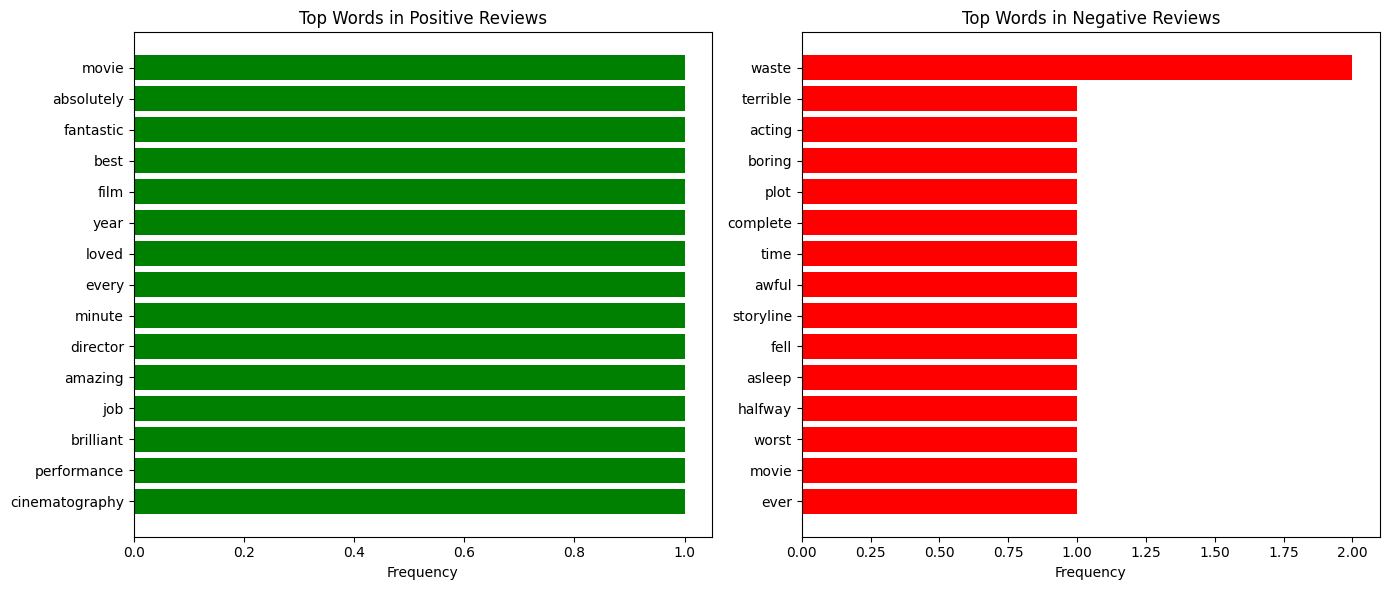

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

for ax, words, title, color in [

    (
        axes[0],
        positive_words,
        "Top Words in Positive Reviews",
        "green"
    ),

    (
        axes[1],
        negative_words,
        "Top Words in Negative Reviews",
        "red"
    )

]:

    labels = [w[0] for w in words]

    counts = [w[1] for w in words]

    ax.barh(labels[::-1], counts[::-1], color=color)

    ax.set_title(title)

    ax.set_xlabel("Frequency")

plt.tight_layout()

plt.savefig("top_words_by_sentiment.png")

plt.show()

### Observation

The visualization shows the most frequent words appearing in positive and negative reviews after preprocessing.

These words help us understand which terms are commonly associated with each sentiment.

# Task 1 Completed

The following preprocessing steps have been completed:

- Text Cleaning
- Tokenization
- Stopword Removal
- Lemmatization
- TF-IDF Vectorization
- Word Frequency Analysis

The processed text is now ready for building the sentiment classification model.

# Task 2: Sentiment Classification

After preprocessing the text data, we can now build a machine learning model to classify movie reviews as either **Positive** or **Negative**.

In this task, we will:

- Encode sentiment labels
- Split the dataset
- Build a Logistic Regression Pipeline
- Train the model
- Make predictions

## Step 31: Encode the Sentiment Labels

Machine learning models require numerical labels instead of text.

Positive → 1

Negative → 0

In [34]:
df["label"] = (df["sentiment"] == "positive").astype(int)

print("Label Distribution:")

print(df["label"].value_counts())

Label Distribution:
label
1    4
0    4
Name: count, dtype: int64


## Step 32: Split the Dataset

Split the reviews into training and testing datasets.

- Training Data → 75%
- Testing Data → 25%

In [35]:
X_train, X_test, y_train, y_test = train_test_split(

    df["cleaned_review"],

    df["label"],

    test_size=0.25,

    random_state=42,

    stratify=df["label"]

)

print("Training Samples :", len(X_train))

print("Testing Samples :", len(X_test))

Training Samples : 6
Testing Samples : 2


## Step 33: Build the Machine Learning Pipeline

The Pipeline combines:

1. TF-IDF Vectorization
2. Logistic Regression Classifier

into one reusable workflow.

In [36]:
from sklearn.pipeline import Pipeline

sentiment_pipeline = Pipeline(

    [

        (

            "tfidf",

            TfidfVectorizer(

                max_features=10000,

                ngram_range=(1,2),

                min_df=1,

                sublinear_tf=True

            )

        ),

        (

            "classifier",

            LogisticRegression(

                max_iter=500,

                C=1.0,

                random_state=42

            )

        )

    ]

)

## Step 34: Train the Pipeline

Train the sentiment classifier using the training dataset.

In [37]:
sentiment_pipeline.fit(

    X_train,

    y_train

)

print("Sentiment Model Trained Successfully!")

Sentiment Model Trained Successfully!


## Step 35: Predict the Test Dataset

After training, the model predicts the sentiment of unseen reviews.

In [38]:
y_pred = sentiment_pipeline.predict(X_test)

print("Predictions:")

print(y_pred)

Predictions:
[1 1]


## Step 36: Compare Actual and Predicted Labels

In [39]:
comparison = pd.DataFrame({

    "Actual": y_test.values,

    "Predicted": y_pred

})

comparison

,Actual,Predicted
0,0,1
1,1,1


### Observation

The trained Logistic Regression model can successfully classify unseen movie reviews into positive or negative sentiments.

# Step 37: Evaluate the Sentiment Model

Now that the model has been trained, we evaluate its performance using several metrics.

The evaluation includes:

- Accuracy Score
- Classification Report
- ROC-AUC Score
- Confusion Matrix

## Calculate Accuracy

In [40]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Accuracy: 50.00%


## Classification Report

The classification report shows:

- Precision
- Recall
- F1-Score
- Support

for each sentiment class.

In [41]:
print("Classification Report\n")

print(

    classification_report(

        y_test,

        y_pred,

        target_names=["Negative", "Positive"]

    )

)

Classification Report

              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00         1
    Positive       0.50      1.00      0.67         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



C:\Users\islam\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\islam\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\islam\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

## ROC-AUC Score

ROC-AUC measures how well the classifier separates positive and negative reviews.

A value closer to **1.0** indicates better performance.

In [42]:
y_proba = sentiment_pipeline.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_proba)

print(f"ROC-AUC Score: {auc:.4f}")

ROC-AUC Score: 0.0000


## Confusion Matrix

The confusion matrix summarizes the prediction results.

- True Positive
- True Negative
- False Positive
- False Negative

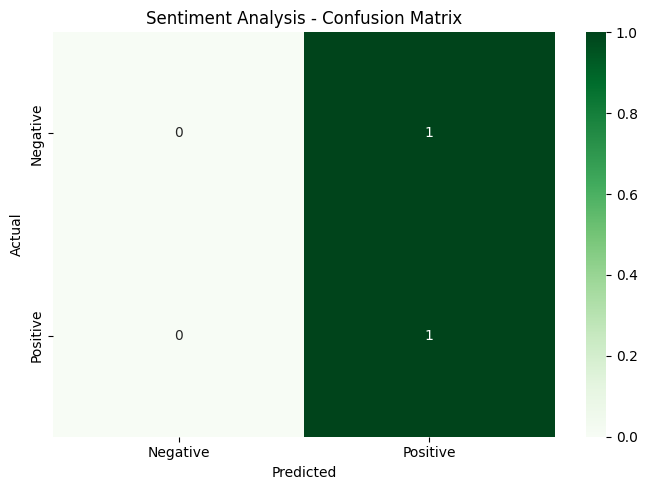

In [43]:
cm = confusion_matrix(

    y_test,

    y_pred

)

plt.figure(figsize=(7,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Greens",

    xticklabels=["Negative","Positive"],

    yticklabels=["Negative","Positive"]

)

plt.title("Sentiment Analysis - Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.tight_layout()

plt.savefig("sentiment_confusion_matrix.png")

plt.show()

## ROC Curve

The ROC Curve visualizes the performance of the classifier at different classification thresholds.

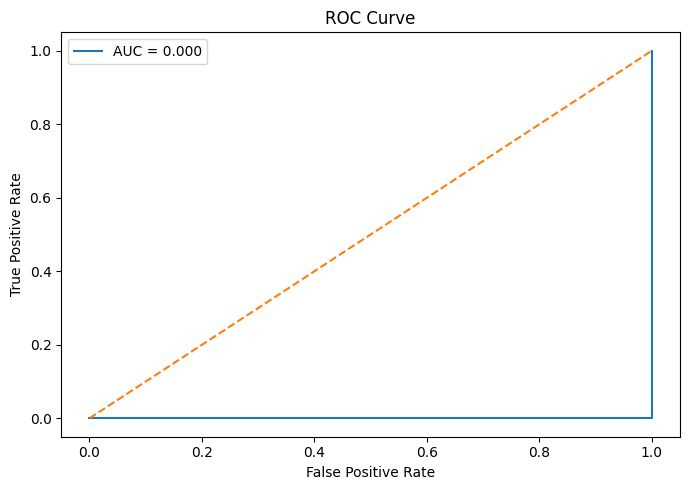

In [44]:
fpr, tpr, thresholds = roc_curve(

    y_test,

    y_proba

)

plt.figure(figsize=(7,5))

plt.plot(

    fpr,

    tpr,

    label=f"AUC = {auc:.3f}"

)

plt.plot(

    [0,1],

    [0,1],

    linestyle="--"

)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.tight_layout()

plt.savefig("roc_curve.png")

plt.show()

### Observation

The evaluation metrics indicate how well the sentiment classifier performs on unseen movie reviews.

Higher Accuracy and ROC-AUC values indicate better classification performance.

# Step 38: Predict Sentiment for New Reviews

The trained model can now predict the sentiment of movie reviews that it has never seen before.

The model will display:

- Predicted Sentiment
- Confidence Score
- Positive Probability
- Negative Probability

## Create Prediction Function

This function accepts any movie review and predicts whether the sentiment is Positive or Negative.

In [46]:
def predict_sentiment(review_text):

    prediction = sentiment_pipeline.predict([review_text])[0]

    probabilities = sentiment_pipeline.predict_proba([review_text])[0]

    label = "POSITIVE" if prediction == 1 else "NEGATIVE"

    confidence = max(probabilities) * 100

    print("=" * 60)

    print("Review:")

    print(review_text)

    print()

    print("Prediction :", label)

    print(f"Confidence : {confidence:.2f}%")

    print(f"Positive Probability : {probabilities[1]*100:.2f}%")

    print(f"Negative Probability : {probabilities[0]*100:.2f}%")

## Test the Model on New Reviews

These reviews are not part of the training dataset.

The model predicts their sentiment automatically.

In [47]:
new_reviews = [

    "This film was absolutely incredible. The acting blew me away!",

    "Complete disaster. Worst screenplay I have ever encountered.",

    "Not bad, some good moments but overall quite mediocre.",

    "The visual effects were stunning and the story was captivating.",

    "I cannot believe how boring this was. Totally disappointed."

]

## Predict Sentiment

In [48]:
for review in new_reviews:

    predict_sentiment(review)

Review:
This film was absolutely incredible. The acting blew me away!

Prediction : POSITIVE
Confidence : 51.88%
Positive Probability : 51.88%
Negative Probability : 48.12%
Review:
Complete disaster. Worst screenplay I have ever encountered.

Prediction : NEGATIVE
Confidence : 52.78%
Positive Probability : 47.22%
Negative Probability : 52.78%
Review:
Not bad, some good moments but overall quite mediocre.

Prediction : NEGATIVE
Confidence : 53.34%
Positive Probability : 46.66%
Negative Probability : 53.34%
Review:
The visual effects were stunning and the story was captivating.

Prediction : POSITIVE
Confidence : 50.00%
Positive Probability : 50.00%
Negative Probability : 50.00%
Review:
I cannot believe how boring this was. Totally disappointed.

Prediction : NEGATIVE
Confidence : 52.78%
Positive Probability : 47.22%
Negative Probability : 52.78%


### Observation

The trained Logistic Regression model can classify completely new movie reviews.

The confidence score represents how certain the model is about each prediction.

# Step 39: Generate Word Clouds

A Word Cloud is a visual representation of the most frequently occurring words.

Larger words indicate higher frequency.

Separate word clouds are created for:

- Positive Reviews
- Negative Reviews

## Create Word Cloud Function

In [49]:
def generate_wordcloud(df_subset, title, colormap, filename):

    all_text = " ".join(df_subset["cleaned_review"])

    wc = WordCloud(

        width=900,

        height=500,

        background_color="white",

        colormap=colormap,

        max_words=150,

        min_font_size=10,

        max_font_size=120,

        collocations=False

    ).generate(all_text)

    plt.figure(figsize=(12,6))

    plt.imshow(wc, interpolation="bilinear")

    plt.axis("off")

    plt.title(title)

    plt.tight_layout()

    plt.savefig(filename)

    plt.show()

## Generate Positive Word Cloud

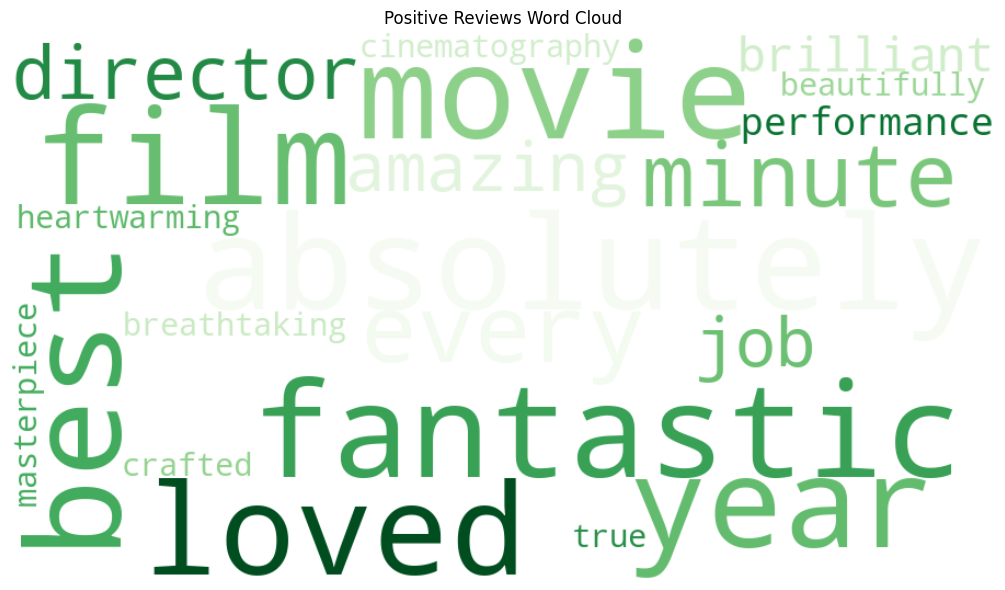

In [50]:
generate_wordcloud(

    df[df["sentiment"]=="positive"],

    "Positive Reviews Word Cloud",

    "Greens",

    "positive_wordcloud.png"

)

## Generate Negative Word Cloud

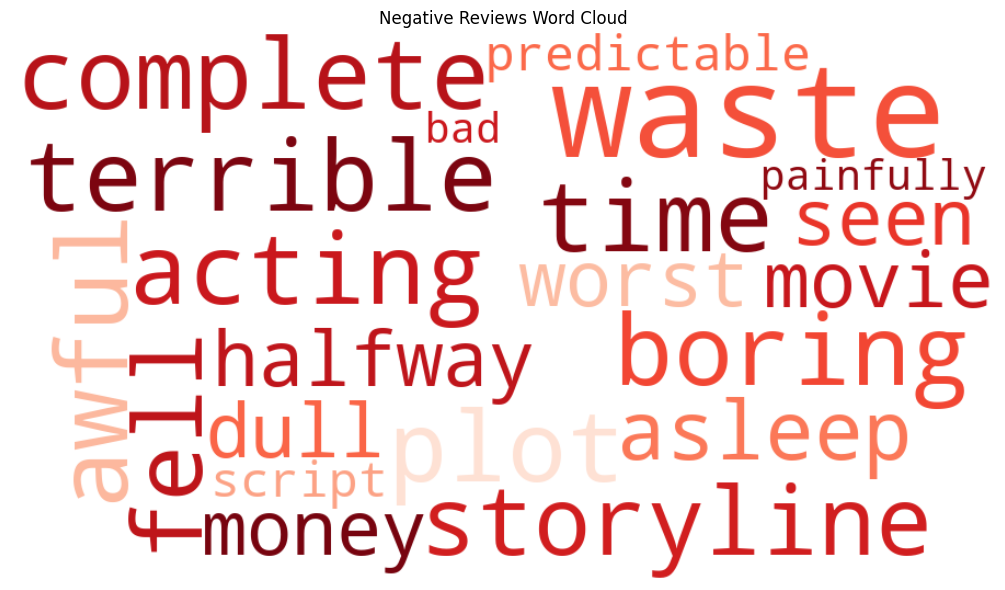

In [51]:
generate_wordcloud(

    df[df["sentiment"]=="negative"],

    "Negative Reviews Word Cloud",

    "Reds",

    "negative_wordcloud.png"

)

### Observation

The positive word cloud highlights frequently occurring positive words, while the negative word cloud emphasizes words commonly associated with negative sentiment.

Word clouds provide an intuitive visualization of important terms in each sentiment class.

# Step 40: Save the Trained Model

After training a machine learning model, it is good practice to save it so that it can be reused without retraining.

In this step, we save the complete sentiment analysis pipeline using Joblib.

In [52]:
joblib.dump(sentiment_pipeline, "sentiment_model.pkl")

print("Model saved successfully!")

Model saved successfully!


# Step 41: Load the Saved Model

The saved model can be loaded at any time for future predictions.

In [53]:
loaded_model = joblib.load("sentiment_model.pkl")

print("Saved model loaded successfully!")

Saved model loaded successfully!


# Step 42: Test the Loaded Model

The loaded model should produce the same predictions as the original model.

In [54]:
sample_review = "This movie was fantastic with brilliant acting."

prediction = loaded_model.predict([sample_review])[0]

probability = loaded_model.predict_proba([sample_review])[0]

print("Review:")
print(sample_review)

print()

print("Prediction:",
      "Positive" if prediction == 1 else "Negative")

print()

print(f"Confidence: {max(probability)*100:.2f}%")

Review:
This movie was fantastic with brilliant acting.

Prediction: Positive

Confidence: 51.88%


# Step 43: Project Summary

This project demonstrates the complete workflow of Natural Language Processing (NLP) and Sentiment Analysis using Python.

The workflow includes:

- Data Loading
- Text Cleaning
- Tokenization
- Stopword Removal
- Stemming
- Lemmatization
- TF-IDF Vectorization
- Word Frequency Analysis
- Logistic Regression Classification
- Model Evaluation
- ROC Curve
- Confusion Matrix
- Sentiment Prediction
- Word Cloud Visualization
- Model Saving and Loading

# Conclusion

In this project, Natural Language Processing techniques were used to preprocess movie reviews and convert text into numerical features using TF-IDF.

A Logistic Regression classifier was trained to classify reviews as Positive or Negative.

The trained model was evaluated using Accuracy, Classification Report, ROC-AUC Score, and Confusion Matrix. Word Clouds were also generated to visualize the most common words in positive and negative reviews.

This project demonstrates a complete end-to-end sentiment analysis workflow using Python and Scikit-learn.